# Post Etruck Model

### Base model functionality
- Inputs
    - PV Installation Size (kWp) and Cost
    - Battery Size (kWh) and Cost
    - Electricity prices: Grid tarif and Feed-in tarif (cent/kWh)
    - Fleet of Etrucks: Any number of *ETrucks* with the following properties
        - Schedule: Hours off driving, can be defined, defaults:
            - `daytime`: like workday, but also on weekends
            - `nighttime`: like worknight, but also on weekends
            - `evening`: offsite driving every weekday, except between 16-19 pm
            - `lunchbreak`: offsite driving every day between 6am - 19pm, except for a 12-2 lunch break
        - Capacity
        - Efficiency
    - PV Yield Timeseries -> *could also be calculated for location* 
    - Monthly schedule to be driven (total km/month):
        - `[57800, 51850, 56100,	53550,	55250,	54400,	54400,	52700,	51000,	57800,	55250,	57800]`
        - `[36750,	39000,	70100,	69000,	78700,	65100,	75200,	66000,	69400,	64500,	60000,	35200]`


- Results
    - Total cost (system cost + operating cost for 10 years)
    - Self-consumption (PV yield used to charge trucks),
    - load-cycles (total battery charge as a fraction of battery capacity)
    - Plots


- **Monthly Schedule (6 pts)**: Add a parameter `monthly_km` to the `simulate()` function, that is a list of monthly km targets. Convert this info in an average km goal per truck per hour per month and use this list to dynamically set the km driven depending on the month. Compare these two schedules for the base truck fleet and one with an optimizied schedule:
    - `[57800, 51850, 56100,	53550,	55250,	54400,	54400,	52700,	51000,	57800,	55250,	57800]`
    - `[36750,	39000,	70100,	69000,	78700,	65100,	75200,	66000,	69400,	64500,	60000,	35200]`
    




[2193.548387096774, 2178.5714285714284, 2129.032258064516, 2100.0, 2096.7741935483873, 2133.3333333333335, 2064.516129032258, 2000.0, 2000.0, 2193.548387096774, 2166.6666666666665, 2193.548387096774]
Energy Flows: 
Grid                426405.0
PV to Truck          33703.0
PV to Battery       151343.0
PV to Grid          230293.0
Battery to Truck    151271.0
Grid to Truck       426405.0
Driven             -721839.0
dtype: float64
PV Yield: 415339 kWh/a
____________________
Total cost: 2_749_439 €/10a
self.system_cost=780_000.0€
self.operating_cost=196_943.9€/a
self.emissions=115129.4kg/a
____________________
Self-consumption: 45%
Load Cycles: 252.2


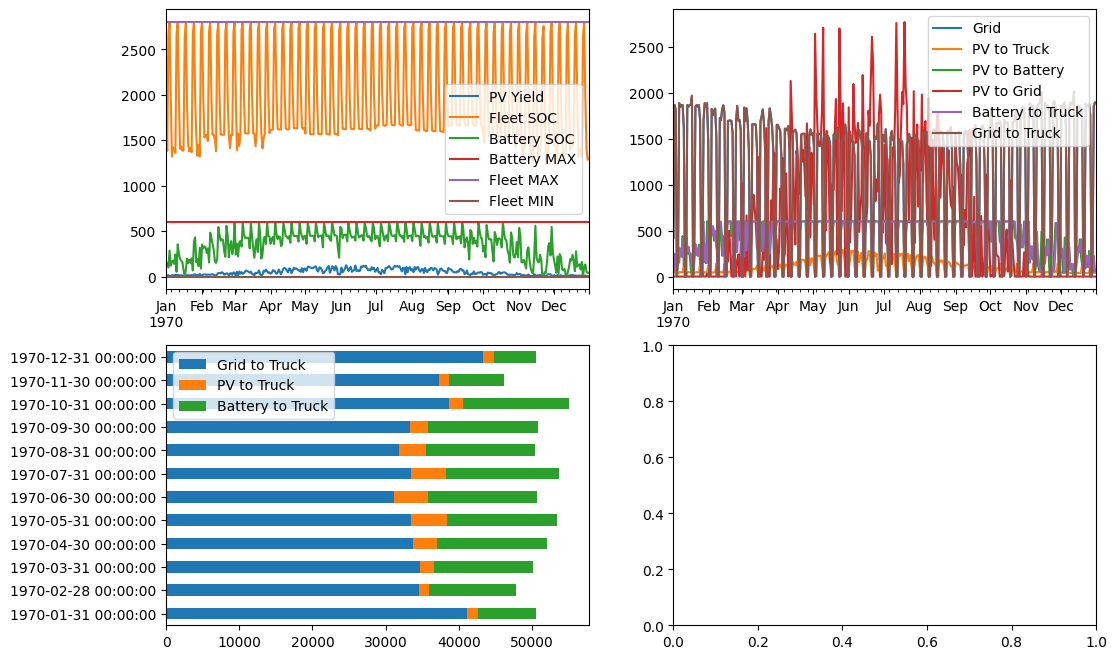

In [13]:
from Model import *


t1 = Etruck(wd_schedule=[1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1],
        we_schedule=[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])

t2 = Etruck(weekly_schedule=[
        [1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,0,0,0,0,0,0,1,1,0,0,0,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,0,0,0,0,0,0,1,1,0,0,0,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,0,0,0,0,0,0,1,1,0,0,0,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]]
        )

trucks = [Etruck("workday") for i in range(5)]
trucks+= [Etruck("worknight") for i in range(2)]
#trucks+= [t1 for i in range(10)]
#trucks+= [t2 for i in range(10)]

results = simulate(start_day=0, 
                    hours=8760, 
                    trucks=trucks, 
                    battery_kWh=600, 
                    pv_kWp=400,
                    monthly_km=[68000,61000,66000,
                                63000,65000,64000,
                                64000,62000,60000,
                                68000,65000,68000,],
                    grid_threshold=0.95,
                    )
results.visualize(("D", "D"))
print(results)


Text(0, 0.5, 'Cost k€')

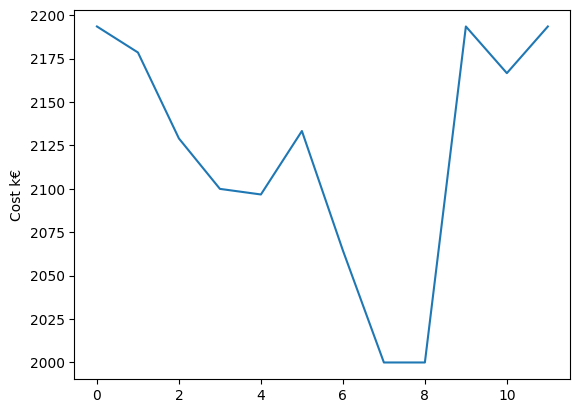

In [2]:

from scipy.optimize import minimize, differential_evolution

bounds2 = [(192,0), (192,400)] #PV, Battery
#options={'gtol': 1e-6, 'eps': 1e-12, 'ftol': 2e-9}

results = opt_results
plt.plot(results)
plt.ylabel("Cost k€")
